# Homework (RUPESH KORAM (DZ93614)) 
Data documentation: https://tidyr.tidyverse.org/reference/who.html

__Directions:__ Answer the three questions below. Create as many code/markdown blocks necessary to answer the questions. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/who.csv')

In [2]:
df.head()

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,...,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
0,Afghanistan,AF,AFG,1980,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AF,AFG,1981,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AF,AFG,1982,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,1983,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,1984,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df.drop(columns=['iso2', 'iso3'])
df.info()
column_names = df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7240 entries, 0 to 7239
Data columns (total 58 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       7240 non-null   object 
 1   year          7240 non-null   int64  
 2   new_sp_m014   3173 non-null   float64
 3   new_sp_m1524  3209 non-null   float64
 4   new_sp_m2534  3206 non-null   float64
 5   new_sp_m3544  3219 non-null   float64
 6   new_sp_m4554  3223 non-null   float64
 7   new_sp_m5564  3218 non-null   float64
 8   new_sp_m65    3209 non-null   float64
 9   new_sp_f014   3174 non-null   float64
 10  new_sp_f1524  3194 non-null   float64
 11  new_sp_f2534  3200 non-null   float64
 12  new_sp_f3544  3199 non-null   float64
 13  new_sp_f4554  3204 non-null   float64
 14  new_sp_f5564  3195 non-null   float64
 15  new_sp_f65    3197 non-null   float64
 16  new_sn_m014   1045 non-null   float64
 17  new_sn_m1524  1030 non-null   float64
 18  new_sn_m2534  1022 non-null 

In [4]:
column_names = df.columns
column_names

Index(['country', 'year', 'new_sp_m014', 'new_sp_m1524', 'new_sp_m2534',
       'new_sp_m3544', 'new_sp_m4554', 'new_sp_m5564', 'new_sp_m65',
       'new_sp_f014', 'new_sp_f1524', 'new_sp_f2534', 'new_sp_f3544',
       'new_sp_f4554', 'new_sp_f5564', 'new_sp_f65', 'new_sn_m014',
       'new_sn_m1524', 'new_sn_m2534', 'new_sn_m3544', 'new_sn_m4554',
       'new_sn_m5564', 'new_sn_m65', 'new_sn_f014', 'new_sn_f1524',
       'new_sn_f2534', 'new_sn_f3544', 'new_sn_f4554', 'new_sn_f5564',
       'new_sn_f65', 'new_ep_m014', 'new_ep_m1524', 'new_ep_m2534',
       'new_ep_m3544', 'new_ep_m4554', 'new_ep_m5564', 'new_ep_m65',
       'new_ep_f014', 'new_ep_f1524', 'new_ep_f2534', 'new_ep_f3544',
       'new_ep_f4554', 'new_ep_f5564', 'new_ep_f65', 'newrel_m014',
       'newrel_m1524', 'newrel_m2534', 'newrel_m3544', 'newrel_m4554',
       'newrel_m5564', 'newrel_m65', 'newrel_f014', 'newrel_f1524',
       'newrel_f2534', 'newrel_f3544', 'newrel_f4554', 'newrel_f5564',
       'newrel_f65'],
   

## Question 1. We need to know what's included in this data.
- How many countries are present?  
- What's the timespan of the data?  
- Does each country have a row for every year present?  
- Which countries are missing years?  
- How many rows have at least 1 non-null values across the columns 3-57?

- How many countries are present?  

In [5]:
# Code
number_of_countries=df['country'].unique()
len(number_of_countries)

219

- What's the timespan of the data?  

In [6]:
min_date=min(df['year'])
max_date=max(df['year'])
print(min_date,"-",max_date)

1980 - 2013


- Does each country have a row for every year present?  

In [7]:
data=[df['year'],df['country']]
data1= pd.DataFrame(data)
data1 = df.pivot(index='country', columns='year', values='year')
missing_values = data1.isna().sum()
if missing_values.max() == 0:
    print("Each country has a row for every year present.")
else:
    print("Not every country has a row for every year present.")


Not every country has a row for every year present.


- Which countries are missing years?

In [8]:
data1 = df.pivot(index='country', columns='year', values='year')
missing_values = data1.isna()
l1=[]
for year, missing in missing_values.items():
    missing_countries = missing.index[missing].tolist()
    if missing_countries:
        print(f"Year {year} has missing data for the following countries:")
        print(", ".join(missing_countries))
    else:
        print(f"Year {year} has data for all countries.")

Year 1980 has missing data for the following countries:
Bonaire, Saint Eustatius and Saba, Curacao, Montenegro, Serbia, Sint Maarten (Dutch part), South Sudan, Timor-Leste
Year 1981 has missing data for the following countries:
Bonaire, Saint Eustatius and Saba, Curacao, Montenegro, Serbia, Sint Maarten (Dutch part), South Sudan, Timor-Leste
Year 1982 has missing data for the following countries:
Bonaire, Saint Eustatius and Saba, Curacao, Montenegro, Serbia, Sint Maarten (Dutch part), South Sudan, Timor-Leste
Year 1983 has missing data for the following countries:
Bonaire, Saint Eustatius and Saba, Curacao, Montenegro, Serbia, Sint Maarten (Dutch part), South Sudan, Timor-Leste
Year 1984 has missing data for the following countries:
Bonaire, Saint Eustatius and Saba, Curacao, Montenegro, Serbia, Sint Maarten (Dutch part), South Sudan, Timor-Leste
Year 1985 has missing data for the following countries:
Bonaire, Saint Eustatius and Saba, Curacao, Montenegro, Serbia, Sint Maarten (Dutch 

- How many rows have at least 1 non-null values across the columns 3-57?

In [9]:

selected_columns = df.iloc[:, 3:58] 
non_null_rows = selected_columns.notnull().any(axis=1)
count_non_null_rows = non_null_rows.sum()
print(f"Number of rows with at least one non-null value in columns 3-57: {count_non_null_rows}")

Number of rows with at least one non-null value in columns 3-57: 3484


## Question 2: Wide data isn't usually helpful.
Convert this to a long format with the following columns:  
1. country  
2. year  
3. diagnosis method: mapping should be: 

```
  {'newsp':'Pulmonary Smear (+)'
  ,'newsn':'Pulmonary Smear (-)'
  ,'newep':'Extrapulmonary'
  ,'newrel':'Relapse'}   
 ```

4. gender: male or female.   
5. age: lower_age - higher_age, e.g., 0-14  
6. number of cases  

__Note__: You can use `replace` (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html)

In [10]:
df.dropna(subset=df.columns.difference(['country', 'year']), how='all', inplace=True)
diagnosis_method_mapping = {
    'newsp': 'Pulmonary Smear (+)',
    'newsn': 'Pulmonary Smear (-)',
    'newep': 'Extrapulmonary',
    'newrel': 'Relapse'
}

country_list = []
year_list = []
diagnosis_method_list = []
gender_list = []
age_list = []
number_of_cases_list = []


for index in range(len(df)):
    row = df.iloc[index]
    for col in df.columns[2:]:
      parts = col.split('_')
      diagnosis_method_code = ""
      gender = ""
      age_group = ""
      if len(parts) >= 3:
        diagnosis_method_code = parts[0] + parts[1]
        gender = parts[2][0:1]
        age_group = parts[2][1:]
      else:
        diagnosis_method_code = parts[0]
        gender = parts[1][0:1]
        age_group = parts[1][1:]

      diagnosis_method = diagnosis_method_mapping.get(diagnosis_method_code, 'Unknown')

      age_range = age_group.replace('014', '0-14').replace('1524', '15-24')
      age_range = age_range.replace('2534', '25-34').replace('3544', '35-44')
      age_range = age_range.replace('4554', '45-54').replace('5564', '55-64').replace('65', '65+')

      gender = gender.replace("m", "male").replace("f", "female")

      country_list.append(row['country'])
      year_list.append(row['year'])
      diagnosis_method_list.append(diagnosis_method)
      gender_list.append(gender)
      age_list.append(age_range)
      number_of_cases_list.append(row[col])

long_data = pd.DataFrame({ 'country': country_list,
    'year': year_list,
    'diagnosis method': diagnosis_method_list,
    'gender': gender_list,
    'age': age_list,
    'number of cases': number_of_cases_list})



In [11]:
long_data.head()

,country,year,diagnosis method,gender,age,number of cases
0,Afghanistan,1997,Pulmonary Smear (+),male,0-14,0.0
1,Afghanistan,1997,Pulmonary Smear (+),male,15-24,10.0
2,Afghanistan,1997,Pulmonary Smear (+),male,25-34,6.0
3,Afghanistan,1997,Pulmonary Smear (+),male,35-44,3.0
4,Afghanistan,1997,Pulmonary Smear (+),male,45-54,5.0


## Question 3: Create a graph that shows when countries started to report TB cases.

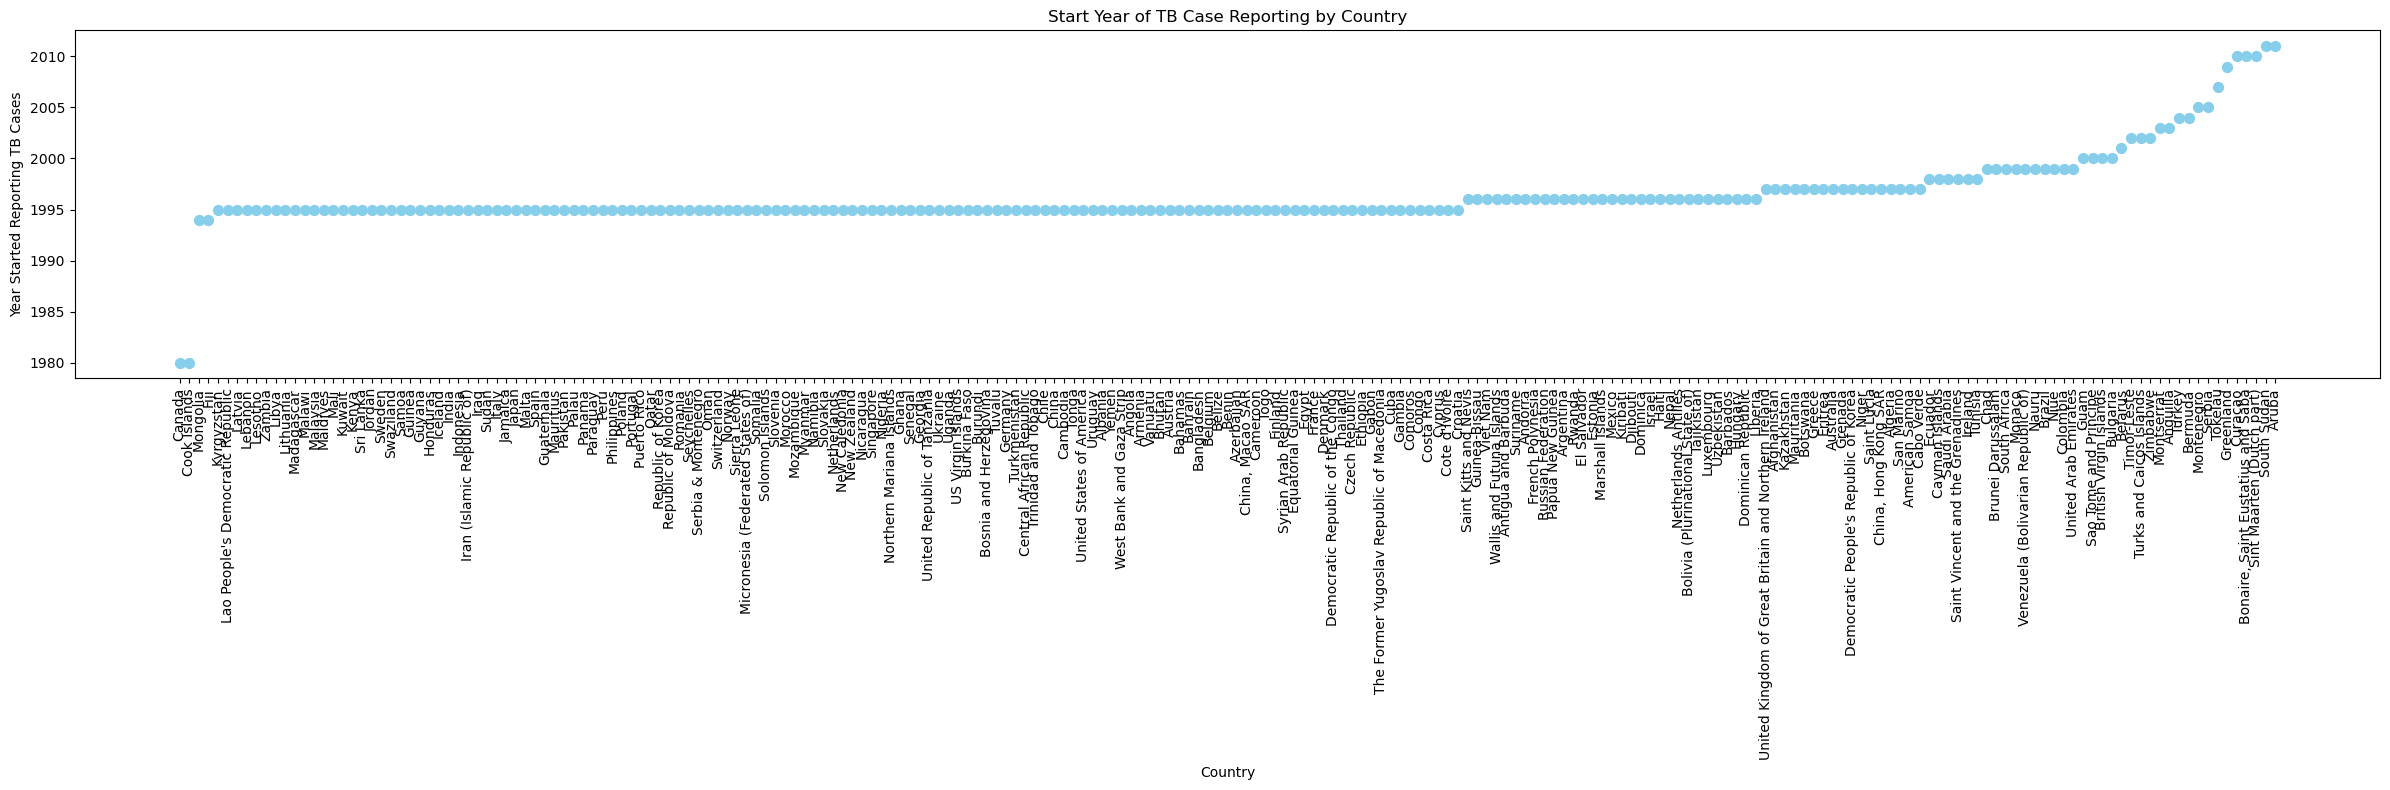

In [14]:
grouped_data = long_data.groupby(['country'])['year'].min().reset_index()

grouped_data.sort_values(by='year', inplace=True)

plt.figure(figsize=(24, 8))
plt.scatter(grouped_data['country'], grouped_data['year'], color='skyblue', marker='o', s=50)
plt.xlabel('Country')
plt.ylabel('Year Started Reporting TB Cases')
plt.title('Start Year of TB Case Reporting by Country')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

